# ==========================================================
# CREDIT CARD FRAUD DETECTION USING DECISION TREE
# ==========================================================

In [ ]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)


In [ ]:
# LOAD DATASET

df = pd.read_csv("creditcard.csv")

print("===================================")
print("DATASET INFORMATION")
print("===================================")

print("\nDataset Shape:")
print(df.shape)

print("\nFirst 5 Rows:")
print(df.head())

DATASET INFORMATION

Dataset Shape:
(284807, 31)

First 5 Rows:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0

In [ ]:
# CHECK DATASET INFO

print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  f

In [ ]:
# CLASS DISTRIBUTION

print("\nFraud vs Non-Fraud Counts:")
print(df['Class'].value_counts())


Fraud vs Non-Fraud Counts:
Class
0    284315
1       492
Name: count, dtype: int64


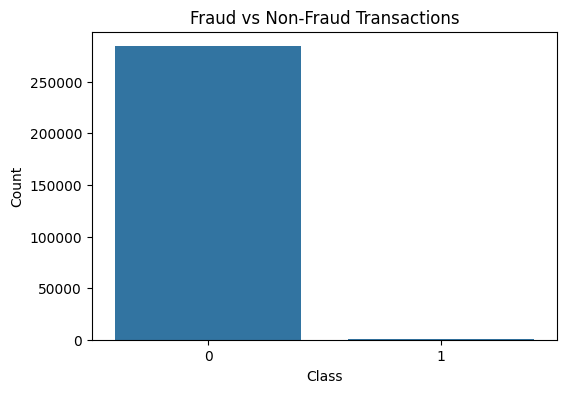

In [ ]:
# VISUALIZE CLASS DISTRIBUTION

plt.figure(figsize=(6,4))

sns.countplot(
    x='Class',
    data=df
)

plt.title("Fraud vs Non-Fraud Transactions")

plt.xlabel("Class")

plt.ylabel("Count")

plt.show()


In [ ]:
# FEATURE & TARGET VARIABLES

X = df.drop('Class', axis=1)

y = df['Class']

In [ ]:
# TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining Data Shape:", X_train.shape)

print("Testing Data Shape:", X_test.shape)


Training Data Shape: (227845, 30)
Testing Data Shape: (56962, 30)


In [ ]:
# DECISION TREE MODEL

dt_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    random_state=42
)

# Train Model
dt_model.fit(X_train, y_train)

print("\nDecision Tree Model Trained Successfully!")


Decision Tree Model Trained Successfully!


In [ ]:
# MODEL PREDICTIONS

y_pred = dt_model.predict(X_test)

y_prob = dt_model.predict_proba(X_test)[:,1]

In [ ]:
# EVALUATION METRICS

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

roc_auc = roc_auc_score(y_test, y_prob)

print("\n===================================")
print("MODEL PERFORMANCE")
print("===================================")

print(f"Accuracy : {accuracy:.4f}")

print(f"Precision: {precision:.4f}")

print(f"Recall   : {recall:.4f}")

print(f"F1 Score : {f1:.4f}")

print(f"ROC AUC  : {roc_auc:.4f}")


MODEL PERFORMANCE
Accuracy : 0.9995
Precision: 0.8941
Recall   : 0.7755
F1 Score : 0.8306
ROC AUC  : 0.9029



CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.89      0.78      0.83        98

    accuracy                           1.00     56962
   macro avg       0.95      0.89      0.92     56962
weighted avg       1.00      1.00      1.00     56962



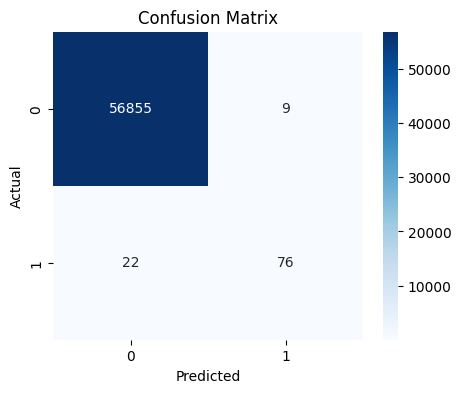

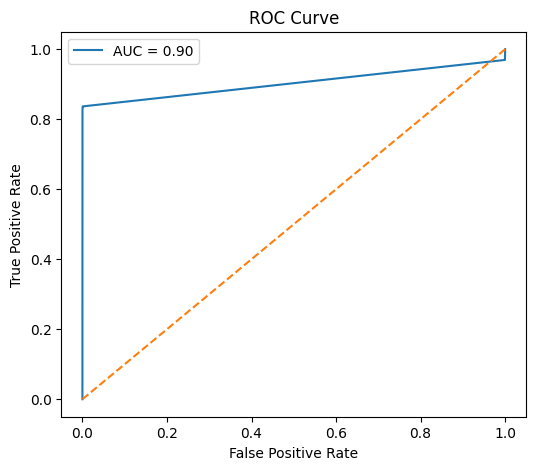

In [ ]:
# CLASSIFICATION REPORT


print("\n===================================")
print("CLASSIFICATION REPORT")
print("===================================")

print(classification_report(y_test, y_pred))


# CONFUSION MATRIX


cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# ROC CURVE


fpr, tpr, threshold = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.2f}"
)

plt.plot([0,1], [0,1], linestyle='--')

plt.title("ROC Curve")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.legend()

plt.show()

In [ ]:
# FEATURE IMPORTANCE


feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print("\n===================================")
print("FEATURE IMPORTANCE")
print("===================================")

print(feature_importance.head(10))


FEATURE IMPORTANCE
   Feature  Importance
17     V17    0.684139
14     V14    0.109765
12     V12    0.073511
10     V10    0.041830
27     V27    0.022993
26     V26    0.022087
16     V16    0.014337
0     Time    0.007272
11     V11    0.006236
7       V7    0.006230


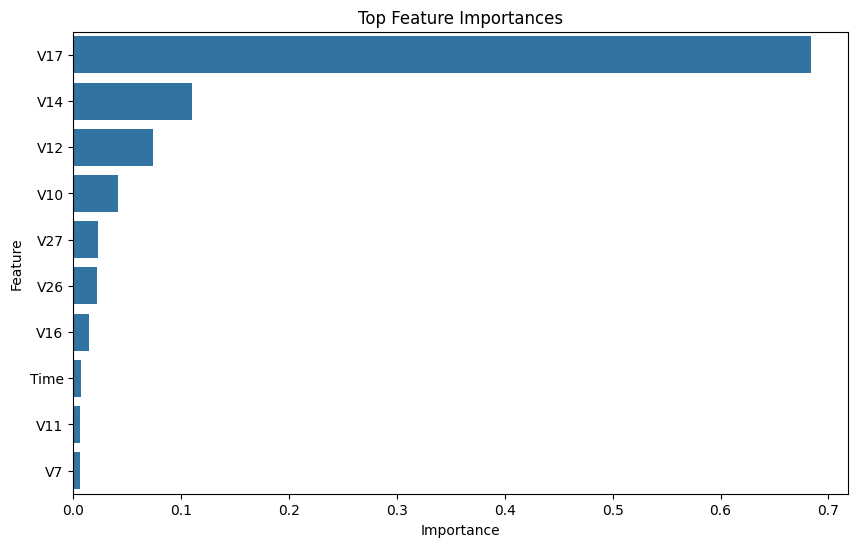

In [ ]:
# FEATURE IMPORTANCE GRAPH

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance.head(10)
)

plt.title("Top Feature Importances")

plt.show()

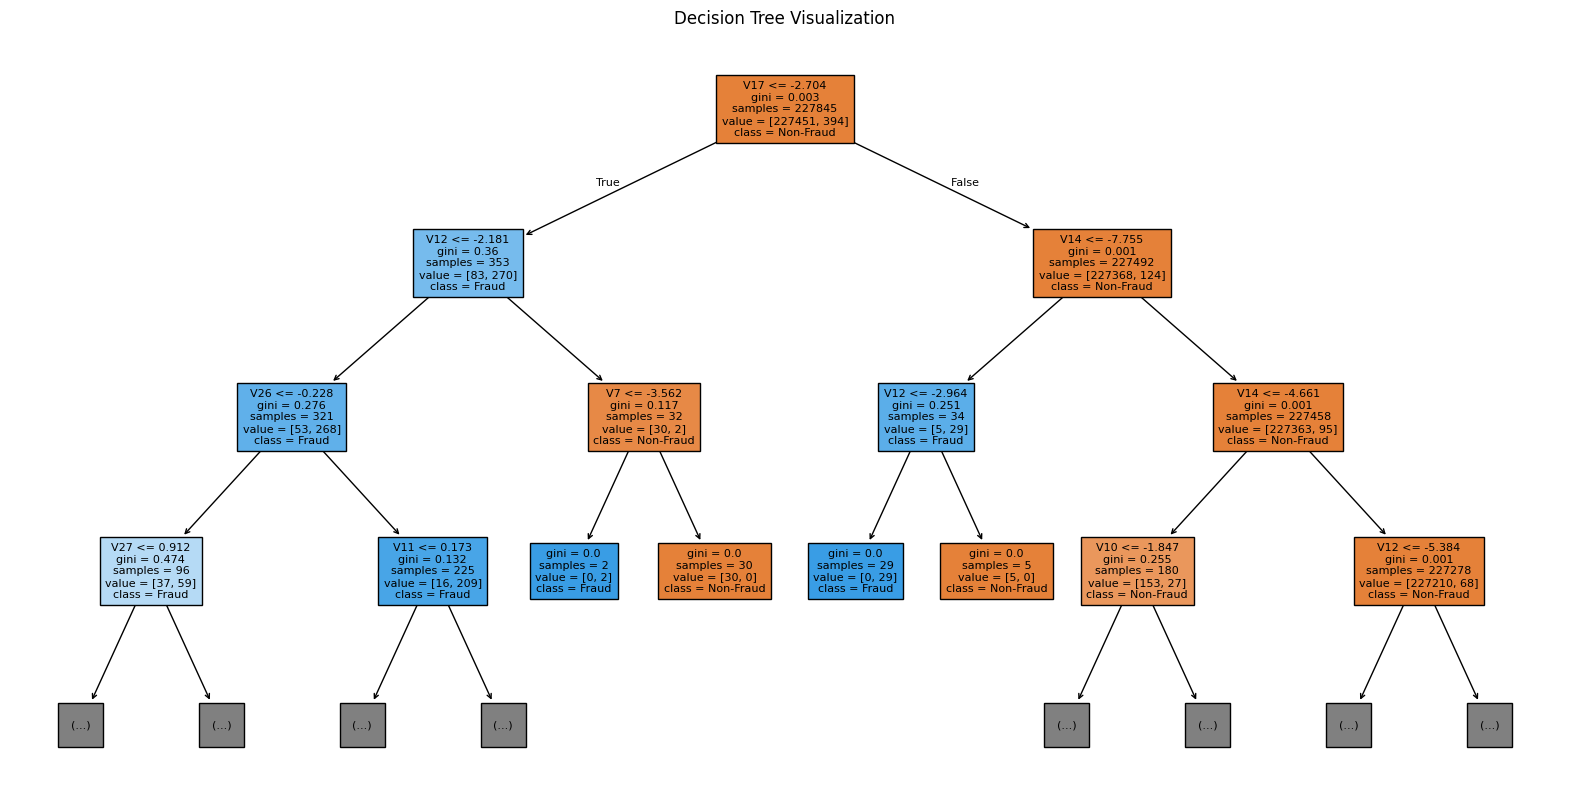

In [ ]:
# DECISION TREE VISUALIZATION

plt.figure(figsize=(20,10))

plot_tree(
    dt_model,
    filled=True,
    fontsize=8,
    max_depth=3,
    feature_names=X.columns,
    class_names=['Non-Fraud', 'Fraud']
)

plt.title("Decision Tree Visualization")

plt.show()

In [ ]:
# PREDICTING NEW TRANSACTION

print("\n===================================")
print("NEW TRANSACTION PREDICTION")
print("===================================")

# Taking one sample transaction
new_transaction = X.iloc[0:1]

# Predict class
prediction = dt_model.predict(new_transaction)

# Predict probabilities
prediction_probability = dt_model.predict_proba(
    new_transaction
)

# Display Prediction
if prediction[0] == 0:

    print("Prediction: Non-Fraudulent Transaction")

else:

    print("Prediction: Fraudulent Transaction")

# Display Probabilities
print("\nPrediction Probabilities:")

print(
    "Non-Fraud Probability:",
    prediction_probability[0][0]
)

print(
    "Fraud Probability:",
    prediction_probability[0][1]
)



NEW TRANSACTION PREDICTION
Prediction: Non-Fraudulent Transaction

Prediction Probabilities:
Non-Fraud Probability: 0.9997182825801795
Fraud Probability: 0.0002817174198205812


In [ ]:
# FINAL SUMMARY

print("\n===================================")
print("PROJECT SUMMARY")
print("===================================")

print("Model Used : Decision Tree Classifier")

print("Task       : Credit Card Fraud Detection")

print("Prediction : Fraud / Non-Fraud")

print("Evaluation Metrics Used:")

print("- Accuracy")
print("- Precision")
print("- Recall")
print("- F1 Score")
print("- ROC-AUC")

print("\nProject Executed Successfully!")


PROJECT SUMMARY
Model Used : Decision Tree Classifier
Task       : Credit Card Fraud Detection
Prediction : Fraud / Non-Fraud
Evaluation Metrics Used:
- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC

Project Executed Successfully!
